# Monte Carlo Cross-Validation — SPR AnoVar (selected hyperparameters)

100 random configurations, 3 training stations, K=2.  
Hyperparameters from HP selection: lambda_pr=0.004, lambda_tmin=0.001, lambda_tmax=0.003.  
Evaluation period: days 365:730 (second year of observations).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Matched RCM data (30 years — spatial patterns and climatology)
data_rcm_pr = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/data_rcm_pr_matched.csv",
    index_col=0
)
data_rcm_tasmin = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/data_rcm_tasmin_matched.csv",
    index_col=0
)
data_rcm_tasmax = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/data_rcm_tasmax_matched.csv",
    index_col=0
)

# Observation data (2 years)
data_obs_precip_raw = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Validation_OBS/Data_clean/data_precip_2yr_clean.csv",
    index_col=0
)
data_obs_tmin_raw = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Validation_OBS/Data_clean/data_tmin_2yr_clean.csv",
    index_col=0
)
data_obs_tmax_raw = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Validation_OBS/Data_clean/data_tmax_2yr_clean.csv",
    index_col=0
)

print(f"RCM precip shape: {data_rcm_pr.shape}")
print(f"Obs precip: {data_obs_precip_raw.shape[1]} stations, {data_obs_precip_raw.shape[0]} days")
print(f"Obs tmin:   {data_obs_tmin_raw.shape[1]} stations, {data_obs_tmin_raw.shape[0]} days")
print(f"Obs tmax:   {data_obs_tmax_raw.shape[1]} stations, {data_obs_tmax_raw.shape[0]} days")

RCM precip shape: (10950, 15)
Obs precip: 15 stations, 730 days
Obs tmin:   44 stations, 730 days
Obs tmax:   44 stations, 730 days


In [3]:
def monthly_climatology(df):
    """
    Monthly climatology (12 x n_stations) from a daily DataFrame.
    Assumes non-leap years (365 days/year).
    """
    Njours_total, Nstations = df.shape
    Nyears = Njours_total // 365
    if Nyears < 1:
        raise ValueError("Input must contain at least 365 days.")
    data_reshaped = df.to_numpy().reshape(Nyears, 365, Nstations)
    days_by_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    month_names = ["January", "February", "March", "April", "May", "June",
                   "July", "August", "September", "October", "November", "December"]
    monthly_means = {}
    start = 0
    for name, ndays in zip(month_names, days_by_month):
        day_indices = list(range(start, start + ndays))
        start += ndays
        data_month = data_reshaped[:, day_indices, :]
        monthly_means[name] = data_month.mean(axis=1).mean(axis=0)
    return pd.DataFrame.from_dict(monthly_means, orient="index", columns=df.columns)


def climatology_fun(climatology, nyears):
    """Expand monthly climatology to a daily array of shape (365*nyears, n_stations)."""
    days_by_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    month_index = np.repeat(np.arange(12), days_by_month)
    climatology_year = climatology.iloc[month_index, :].values   # (365, n_stations)
    return np.tile(climatology_year, (nyears, 1))                 # (365*nyears, n_stations)

In [4]:
# --- RCM grid (full period, for SVD and climatology) ---
data_pr_grid     = data_rcm_pr.copy()
data_pr_grid[data_pr_grid < 0.5] = 0
data_tasmin_grid = data_rcm_tasmin.copy()
data_tasmax_grid = data_rcm_tasmax.copy()

n_years_rcm = data_pr_grid.shape[0] // 365
print(f"RCM years for climatology: {n_years_rcm}")

# Monthly climatology from full RCM
climatology_pr     = monthly_climatology(data_pr_grid)
climatology_tasmin = monthly_climatology(data_tasmin_grid)
climatology_tasmax = monthly_climatology(data_tasmax_grid)

# Daily climatology for full RCM period
clim_rcm_pr     = climatology_fun(climatology_pr,     nyears=n_years_rcm)
clim_rcm_tasmin = climatology_fun(climatology_tasmin, nyears=n_years_rcm)
clim_rcm_tasmax = climatology_fun(climatology_tasmax, nyears=n_years_rcm)

# RCM anomalies (full period, for SVD)
anomaly_rcm_pr_np     = data_pr_grid.values / clim_rcm_pr - 1       # multiplicative, centered at 0
anomaly_rcm_tasmin_np = data_tasmin_grid.values - clim_rcm_tasmin    # additive
anomaly_rcm_tasmax_np = data_tasmax_grid.values - clim_rcm_tasmax    # additive

# --- Observation data ---
EVAL_DAY_SLICE = slice(365, 730)   # second year

# Precip: softplus-inverse transform (log space)
obs_pr_raw_np = data_obs_precip_raw.values.astype(float).copy()
obs_pr_for_metrics = obs_pr_raw_np.copy()
obs_pr_for_metrics[obs_pr_for_metrics < 0.5] = 0

obs_pr_for_spr = obs_pr_raw_np.copy()
obs_pr_for_spr[obs_pr_for_spr <= 1e-5] = 1e-5
obs_pr_for_spr = np.log(np.exp(obs_pr_for_spr) - 1)

# Tmin / Tmax (no transform)
obs_tmin_np = data_obs_tmin_raw.values.astype(float).copy()
obs_tmax_np = data_obs_tmax_raw.values.astype(float).copy()

# Daily climatology for eval period (1 year = 365 days)
clim_eval_pr     = climatology_fun(climatology_pr,     nyears=1)   # (365, n_pr)
clim_eval_tasmin = climatology_fun(climatology_tasmin, nyears=1)   # (365, n_tmin)
clim_eval_tasmax = climatology_fun(climatology_tasmax, nyears=1)   # (365, n_tmax)

# Pre-computed obs anomalies for eval period (NaN masking done per iteration in MC loop)
obs_pr_spr_eval = obs_pr_for_spr[EVAL_DAY_SLICE, :]    # (365, n_pr), log space
obs_tmin_eval   = obs_tmin_np[EVAL_DAY_SLICE, :]        # (365, n_tmin)
obs_tmax_eval   = obs_tmax_np[EVAL_DAY_SLICE, :]        # (365, n_tmax)

anomaly_pr_obs_eval    = obs_pr_spr_eval / clim_eval_pr - 1   # (365, n_pr), centered at 0
anomaly_tmin_obs_eval  = obs_tmin_eval - clim_eval_tasmin      # (365, n_tmin)
anomaly_tmax_obs_eval  = obs_tmax_eval - clim_eval_tasmax      # (365, n_tmax)

# Obs for metrics (eval period)
obs_pr_metrics_eval   = obs_pr_for_metrics[EVAL_DAY_SLICE, :]
obs_tmin_metrics_eval = obs_tmin_eval.copy()
obs_tmax_metrics_eval = obs_tmax_eval.copy()

n_total_pr     = anomaly_pr_obs_eval.shape[1]
n_total_tasmin = anomaly_tmin_obs_eval.shape[1]
n_total_tasmax = anomaly_tmax_obs_eval.shape[1]

print(f"n_total_pr={n_total_pr}, n_total_tasmin={n_total_tasmin}, n_total_tasmax={n_total_tasmax}")
print(f"anomaly_rcm_pr shape:      {anomaly_rcm_pr_np.shape}")
print(f"anomaly_pr_obs_eval shape: {anomaly_pr_obs_eval.shape}")
print(f"clim_eval_pr shape:        {clim_eval_pr.shape}")

RCM years for climatology: 30
n_total_pr=15, n_total_tasmin=44, n_total_tasmax=44
anomaly_rcm_pr shape:      (10950, 15)
anomaly_pr_obs_eval shape: (365, 15)
clim_eval_pr shape:        (365, 15)


In [5]:
# ============================================================
# TEMPERATURE
# ============================================================
def spr_interp_anomaly_temp_var_em(anomaly_rcm_grid, anomaly_obs_grid, climatology_obs_grid,
                                    n_spatterns=10, n_jobs=-1, lambda_var=1e-10,
                                    max_iter=20, tol=1e-4, init_A='zero',
                                    ridge_var=False, gamma_ridge_var=0, 
                                    ridge_betas=False, gamma_ridge_betas=0,
                                    verbose=True):
    """
    SPR interpolation with EM optimization starting from A = 0.
    lambda_var = 0 correspond to no VAR(1) smoothing
    Algorithm:
    ----------
    1. Initialize A = 0 (or A = I)
    2. Step I: Estimate weights B with fixed A via regularized least squares
    3. Step II: Estimate transition matrix A with fixed B via OLS regression
    4. Repeat until convergence
    
    Parameters
    ----------
    init_A : str, {'zero', 'identity'}
        Initialization for A matrix
    max_iter : int
        Maximum EM iterations
    tol : float
        Convergence tolerance on cost function
    
    Returns
    -------
    data_interp_spr : np.ndarray (T, D)
    B : np.ndarray (T, K) - optimized weights
    A_est : np.ndarray (K, K) - optimized transition matrix
    costs : list - cost function history
    """
    
    # Convert inputs
    anomaly_rcm_grid = anomaly_rcm_grid.values if isinstance(anomaly_rcm_grid, pd.DataFrame) else anomaly_rcm_grid
    anomaly_obs_grid = anomaly_obs_grid.values if isinstance(anomaly_obs_grid, pd.DataFrame) else anomaly_obs_grid
    climatology_obs_grid = climatology_obs_grid.values if isinstance(climatology_obs_grid, pd.DataFrame) else climatology_obs_grid
    
    # Step 1: SVD decomposition
    svd_rcm = TruncatedSVD(n_components=n_spatterns, random_state=0)
    svd_rcm.fit(anomaly_rcm_grid)
    spatterns = svd_rcm.components_.T  # (D_full, K)
    
    # Step 2: Remove missing columns
    first_day = anomaly_obs_grid[0, :]
    indexes_NA_col = np.where(np.isnan(first_day))[0]
    data_valid = np.delete(anomaly_obs_grid, indexes_NA_col, axis=1)  # (T, D_obs)
    spatterns_model = np.delete(spatterns, indexes_NA_col, axis=0)  # (D_obs, K)
    
    T = anomaly_obs_grid.shape[0]
    K = n_spatterns
    V = spatterns_model  # shorthand
    
    # Check if VAR component is needed
    use_var = lambda_var >= 1e-8 # Ou prendre une valeur encore plus petite pour être sûr de ne pas activer le VAR ?
    if verbose:
        if use_var:
            print(f"Using VAR(1) temporal component (λ={lambda_var:.6f})")
        else:
            print(f"λ={lambda_var:.6f} ≈ 0 → No VAR component (independent temporal estimation)")
    
    # ============================================================
    # INITIALIZATION: A = 0 or A = I
    # ============================================================
    if use_var:
        if init_A == 'zero':
            A_est = np.zeros((K, K))
        elif init_A == 'identity':
            A_est = np.eye(K)
        else:
            raise ValueError("init_A must be 'zero' or 'identity'")
        
        if verbose:
            print(f"Initialized A with {init_A} matrix")
    else:
        # No VAR: A is not needed
        A_est = np.zeros((K, K))
        rho = 0.0
    
    # ============================================================
    # COST FUNCTION
    # ============================================================
    def compute_cost(B_mat, A_mat, data, V_mat, lam):
        """
        J(B, A) = ||Y - VB^T||^2_F + lambda * ||B_{2:T} - A B_{1:T-1}||^2_F
        """
        # Reconstruction error: sum_t ||y_t - V*beta_t||^2
        recon_error = 0.0
        for t in range(T):
            y_t = data[t, :]
            y_hat_t = V_mat @ B_mat[t, :]
            recon_error += np.sum((y_t - y_hat_t) ** 2)
        
        # Temporal penalty: sum_{t=2}^T ||beta_t - A*beta_{t-1}||^2
        temp_penalty = 0.0
        if lam >= 1e-8: # Seuil pour éviter de calculer la pénalité si lambda est très petit (pas de VAR)
            for t in range(1, T):
                residual = B_mat[t, :] - A_mat @ B_mat[t-1, :]
                temp_penalty += np.sum(residual ** 2)
        
        return recon_error + lam * temp_penalty
    
    # ============================================================
    # EM ITERATIONS
    # ============================================================
    costs = []
    B = None  # Will be initialized in first iteration
    
    for iteration in range(max_iter):
        # --------------------------------------------------------
        # STEP I: Estimate weights B with fixed A
        # --------------------------------------------------------
        # Each time step is an independent quadratic problem:
        # beta_t = argmin ||y_t - V*beta||^2 + lambda ||beta - A*beta_{t-1}||^2
        
        B_new = np.zeros((T, K))
        
        # First time step (no temporal prior)
        y_0 = data_valid[0, :]
        if ridge_betas:
            G_0 = V.T @ V + gamma_ridge_betas * np.eye(K)
        else:
            G_0 = V.T @ V + 1e-4 * np.eye(K)  # numerical stability
        rhs_0 = V.T @ y_0
        B_new[0, :] = np.linalg.solve(G_0, rhs_0)
        
        # Subsequent time steps (with temporal regularization if VAR is used)
        for t in range(1, T): # range 1 to T-1
            y_t = data_valid[t, :]
            
            if use_var:
                # Solve: (V^T V + lambda*I) beta_t = V^T y_t + lambda*A*beta_{t-1}
                if ridge_betas:
                    G = V.T @ V + lambda_var * np.eye(K) + gamma_ridge_betas * np.eye(K)
                else:
                    G = V.T @ V + lambda_var * np.eye(K) + 1e-4 * np.eye(K)  # numerical stability
                
                rhs = V.T @ y_t + lambda_var * (A_est @ B_new[t-1, :])
            else:
                # No VAR: each time step is independent
                if ridge_betas:
                    G = V.T @ V + gamma_ridge_betas * np.eye(K)
                else:
                    G = V.T @ V + 1e-4 * np.eye(K) # numerical stability
                rhs = V.T @ y_t
            
            B_new[t, :] = np.linalg.solve(G, rhs)
        
        B = B_new
        
        # --------------------------------------------------------
        # STEP II: Estimate transition matrix A with fixed B
        # --------------------------------------------------------
        if use_var:            
            B_past = B[:-1, :]      # B_{1:T-1}, shape (T-1, K)
            B_future = B[1:, :]     # B_{2:T}, shape (T-1, K)
            
            # Compute A via OLS regression (each row k of A independently)            
            Gram = B_past.T @ B_past  # (K, K)
            
            if ridge_var:
                Gram_reg = Gram + gamma_ridge_var * np.eye(K)
            else:
                Gram_reg = Gram + 1e-4 * np.eye(K)  # numerical stability
            
            # Moore-Penrose pseudo-inverse (or regular inverse if full rank)
            try:
                Gram_inv = np.linalg.inv(Gram_reg)
            except np.linalg.LinAlgError:
                Gram_inv = np.linalg.pinv(Gram_reg)
            
            A_est = B_future.T @ B_past @ Gram_inv  # (K, K)
            
            # Check for NaN/Inf in A_est before computing eigenvalues
            if not np.isfinite(A_est).all():
                raise ValueError(
                    f"A_est contains NaN or Inf values. This typically indicates numerical instability. "
                    f"Try increasing lambda_var (current: {lambda_var}) or reducing n_spatterns (current: {n_spatterns})."
                )
            
            # Apply stability constraint: spectral radius < 1
            rho = np.max(np.abs(np.linalg.eigvals(A_est)))
            if rho > 1:
                A_est = A_est / (rho + 1e-4)  # scale down
                if verbose and iteration == 0:
                    print(f"  Applied spectral radius normalization (ρ={rho:.4f})")
        # else: A_est and rho already set above (no update needed)
        
        # --------------------------------------------------------
        # CHECK CONVERGENCE
        # --------------------------------------------------------
        current_cost = compute_cost(B, A_est, data_valid, V, lambda_var)
        costs.append(current_cost)
        if iteration > 0:
            cost_change = abs(current_cost - prev_cost) / (prev_cost + 1e-4)  # relative change
            if verbose:
                if use_var:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}, "
                          f"ΔCost = {cost_change:.6e}, ||A||_F = {np.linalg.norm(A_est, 'fro'):.4f}, "
                          f"ρ(A) = {rho:.4f}")
                else:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}, "
                          f"ΔCost = {cost_change:.6e}")
            if cost_change < tol:
                if verbose:
                    print(f"✓ Converged after {iteration+1} iterations")
                break
        else:
            if verbose:
                if use_var:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}, "
                          f"||A||_F = {np.linalg.norm(A_est, 'fro'):.4f}")
                else:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}")
        prev_cost = current_cost
    
    # ============================================================
    # RECONSTRUCTION
    # ============================================================
    def reconstruct_day(t):
        beta_t = B[t, :].reshape(-1, 1)
        anomaly_reconstructed = spatterns @ beta_t
        rec = anomaly_reconstructed + climatology_obs_grid[t, :].reshape(-1, 1)
        return rec.ravel()
    
    interpolated_days = Parallel(n_jobs=n_jobs)(
        delayed(reconstruct_day)(t) for t in tqdm(range(T), desc="Reconstructing")
    )
    data_interp_spr = np.vstack(interpolated_days)
    anomaly_interp_spr = data_interp_spr - climatology_obs_grid # mean ~ 0
    
    return data_interp_spr


# ============================================================
# PRECIPITATION
# ============================================================
def spr_interp_anomaly_precip_var_em(anomaly_rcm_grid, anomaly_obs_grid, climatology_obs_grid,
                                     n_spatterns=10, n_jobs=-1, lambda_var=0.001,
                                     max_iter=20, tol=1e-4, init_A='zero',
                                     ridge_var=False, gamma_ridge_var=0,
                                     ridge_betas=False, gamma_ridge_betas=0,
                                     verbose=True):
    """
    EM optimization for precipitation (multiplicative anomalies).
    Anomalies are centered (mean ~ 0). The model does not center them during the optimization.
    lambda_var = 0 correspond to no VAR(1) smoothing
    """
    
    # Convert inputs
    anomaly_rcm_grid = anomaly_rcm_grid.values if isinstance(anomaly_rcm_grid, pd.DataFrame) else anomaly_rcm_grid
    anomaly_obs_grid = anomaly_obs_grid.values if isinstance(anomaly_obs_grid, pd.DataFrame) else anomaly_obs_grid
    climatology_obs_grid = climatology_obs_grid.values if isinstance(climatology_obs_grid, pd.DataFrame) else climatology_obs_grid
    
    # SVD with centering
    scaler = StandardScaler(with_mean=True, with_std=False)
    anomaly_rcm_grid_scaled = scaler.fit_transform(anomaly_rcm_grid)
    centres_pca = scaler.mean_
    svd_rcm = TruncatedSVD(n_components=n_spatterns, random_state=0)
    svd_rcm.fit(anomaly_rcm_grid_scaled)
    spatterns = svd_rcm.components_.T
    
    # Remove missing columns
    first_day = anomaly_obs_grid[0, :]
    indexes_NA_col = np.where(np.isnan(first_day))[0]
    data_valid = np.delete(anomaly_obs_grid, indexes_NA_col, axis=1)
    spatterns_model = np.delete(spatterns, indexes_NA_col, axis=0)
    
    T = anomaly_obs_grid.shape[0]
    K = n_spatterns
    V = spatterns_model
    
    # Check if VAR component is needed
    use_var = lambda_var >= 1e-8
    if verbose:
        if use_var:
            print(f"Using VAR(1) temporal component (λ={lambda_var:.6f})")
        else:
            print(f"λ={lambda_var:.6f} ≈ 0 → No VAR component (independent temporal estimation)")
    
    # Initialize A
    if use_var:
        if init_A == 'zero':
            A_est = np.zeros((K, K))
        elif init_A == 'identity':
            A_est = np.eye(K)
        else:
            raise ValueError("init_A must be 'zero' or 'identity'")
        
        if verbose:
            print(f"Initialized A with {init_A} matrix")
    else:
        # No VAR: A is not needed
        A_est = np.zeros((K, K))
        rho = 0.0
    
    # Cost function
    def compute_cost_precip(B_mat, A_mat, data, V_mat, lam):
        recon_error = 0.0
        for t in range(T):
            y_centered = data[t, :]  # Deja centré. 
            y_hat_centered = V_mat @ B_mat[t, :]
            recon_error += np.sum((y_centered - y_hat_centered) ** 2)
        
        temp_penalty = 0.0
        if lam >= 1e-8:
            for t in range(1, T):
                residual = B_mat[t, :] - A_mat @ B_mat[t-1, :]
                temp_penalty += np.sum(residual ** 2)
        
        return recon_error + lam * temp_penalty
    
    costs = []
    B = None
    
    # EM iterations
    for iteration in range(max_iter):
        # STEP I: Estimate B with fixed A
        B_new = np.zeros((T, K))
        
        # First time step
        y_0_centered = data_valid[0, :] # Deja centré.
        if ridge_betas:
            G_0 = V.T @ V + gamma_ridge_betas * np.eye(K)
        else:
            G_0 = V.T @ V + 1e-4 * np.eye(K)
        rhs_0 = V.T @ y_0_centered
        B_new[0, :] = np.linalg.solve(G_0, rhs_0)
        
        # Subsequent time steps
        for t in range(1, T):
            y_centered = data_valid[t, :] # Deja centré
            
            if use_var:
                if ridge_betas:
                    G = V.T @ V + lambda_var * np.eye(K) + gamma_ridge_betas * np.eye(K)
                else:
                    G = V.T @ V + lambda_var * np.eye(K) + 1e-4 * np.eye(K) # numerical stability
                rhs = V.T @ y_centered + lambda_var * (A_est @ B_new[t-1, :])
            else:
                # No VAR: each time step is independent
                if ridge_betas:
                    G = V.T @ V + gamma_ridge_betas * np.eye(K)
                else:
                    G = V.T @ V + 1e-4 * np.eye(K) # numerical stability
                rhs = V.T @ y_centered
            
            B_new[t, :] = np.linalg.solve(G, rhs)
        
        B = B_new
        
        # STEP II: Estimate A with fixed B
        if use_var:
            B_past = B[:-1, :]
            B_future = B[1:, :]
            Gram = B_past.T @ B_past
            
            if ridge_var:
                Gram_reg = Gram + gamma_ridge_var * np.eye(K)
            else:
                Gram_reg = Gram + 1e-4 * np.eye(K) # numerical stability
            
            try:
                Gram_inv = np.linalg.inv(Gram_reg)
            except np.linalg.LinAlgError:
                Gram_inv = np.linalg.pinv(Gram_reg)
            
            A_est = B_future.T @ B_past @ Gram_inv
            
            # Check for NaN/Inf in A_est before computing eigenvalues
            if not np.isfinite(A_est).all():
                raise ValueError(
                    f"A_est contains NaN or Inf values. This typically indicates numerical instability. "
                    f"Try increasing lambda_var (current: {lambda_var}) or reducing n_spatterns (current: {n_spatterns})."
                )
            
            # Stability constraint
            rho = np.max(np.abs(np.linalg.eigvals(A_est)))
            if rho > 1:
                A_est = A_est / (rho + 1e-4)
        # else: A_est and rho already set above
        
        # Check convergence
        current_cost = compute_cost_precip(B, A_est, data_valid, V, lambda_var)
        costs.append(current_cost)
        
        if iteration > 0:
            cost_change = abs(current_cost - prev_cost) / (prev_cost + 1e-12)
            if verbose:
                if use_var:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}, "
                          f"ΔCost = {cost_change:.6e}, ρ(A) = {rho:.4f}")
                else:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}, "
                          f"ΔCost = {cost_change:.6e}")
            if cost_change < tol:
                if verbose:
                    print(f"✓ Converged after {iteration+1} iterations")
                break
        else:
            if verbose:
                print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}")
        
        prev_cost = current_cost
    
    # Reconstruction
    def reconstruct_day(t):
        beta_t = B[t, :].reshape(-1, 1)
        anomaly_centered = spatterns @ beta_t
        rec = (anomaly_centered + 1) * climatology_obs_grid[t, :].reshape(-1, 1)
        # rec[rec < 0.5] = 0
        return rec.ravel()
    
    interpolated_days = Parallel(n_jobs=n_jobs)(
        delayed(reconstruct_day)(t) for t in tqdm(range(T), desc="Reconstructing")
    )
    data_interp_spr = np.vstack(interpolated_days)
    anomaly_interp_spr = data_interp_spr / climatology_obs_grid # mean ~ 1
    
    return data_interp_spr

In [6]:
def mean_daily_rmse(mod, obs):
    """Spatial RMSE: per-day sqrt(mean_stations(err²)), averaged over days."""
    M = np.asarray(mod, dtype=float)
    O = np.asarray(obs, dtype=float)
    return float(np.nanmean(np.sqrt(np.nanmean((M - O) ** 2, axis=1))))


def mean_station_ssim(mod, obs, K1=0.01, K2=0.03, L=None, eps=1e-12):
    """SSIM averaged over stations (each computed over its full time series)."""
    M = np.asarray(mod, dtype=float)
    O = np.asarray(obs, dtype=float)
    station_ssim = []
    for s in range(M.shape[1]):
        a, b = M[:, s], O[:, s]
        mask = np.isfinite(a) & np.isfinite(b)
        if mask.sum() < 2:
            station_ssim.append(np.nan)
            continue
        a, b   = a[mask], b[mask]
        mu_a, mu_b = a.mean(), b.mean()
        var_a  = np.mean((a - mu_a) ** 2)
        var_b  = np.mean((b - mu_b) ** 2)
        sig_a, sig_b = np.sqrt(var_a), np.sqrt(var_b)
        cov_ab = np.mean((a - mu_a) * (b - mu_b))
        if L is None:
            L_s = np.max(b) - np.min(b)
            if L_s < eps:
                L_s = max(abs(mu_b), eps)
        else:
            L_s = L
        C1, C2 = (K1 * L_s) ** 2, (K2 * L_s) ** 2
        C3 = C2 / 2.0
        l  = (2 * mu_a * mu_b + C1)   / (mu_a**2 + mu_b**2 + C1)
        c  = (2 * sig_a * sig_b + C2) / (var_a + var_b + C2)
        sv = (cov_ab + C3)             / (sig_a * sig_b + C3)
        station_ssim.append(l * c * sv)
    return float(np.nanmean(station_ssim))


def interday_variability(arr):
    """Mean absolute day-to-day difference, averaged over stations."""
    A = np.asarray(arr, dtype=float)
    return float(np.nanmean(np.nanmean(np.abs(np.diff(A, axis=0)), axis=1)))


def mean_acf_lag1(arr):
    """ACF at lag 1 averaged over stations."""
    A = np.asarray(arr, dtype=float)
    acf_vals = []
    for s in range(A.shape[1]):
        x = A[:, s]
        mask = np.isfinite(x)
        if mask.sum() < 3:
            continue
        x = x[mask]
        x_c = x - x.mean()
        var = np.mean(x_c ** 2)
        if var < 1e-12:
            continue
        acf_vals.append(float(np.mean(x_c[:-1] * x_c[1:]) / var))
    return float(np.nanmean(acf_vals)) if acf_vals else np.nan


In [7]:
N_CONFIGS   = 100
N_TRAIN     = 3
N_SPATTERNS = 2    # K = 2

EVAL_DAY_SLICE = slice(365, 730)
SEEDS = list(range(N_CONFIGS))

# Selected hyperparameters
LAMBDA_PR   = 0.04
LAMBDA_TMIN = 0.001
LAMBDA_TMAX = 0.003

print(f"N_CONFIGS={N_CONFIGS}, N_TRAIN={N_TRAIN}, K={N_SPATTERNS}")
print(f"LAMBDA_PR={LAMBDA_PR}, LAMBDA_TMIN={LAMBDA_TMIN}, LAMBDA_TMAX={LAMBDA_TMAX}")

N_CONFIGS=100, N_TRAIN=3, K=2
LAMBDA_PR=0.04, LAMBDA_TMIN=0.001, LAMBDA_TMAX=0.003


In [8]:
results_pr = []

for seed in tqdm(SEEDS, desc="PRECIP"):
    np.random.seed(seed)
    train_idx = np.sort(np.random.choice(n_total_pr, size=N_TRAIN, replace=False))
    test_idx  = np.array([i for i in range(n_total_pr) if i not in train_idx])

    anomaly_mc = anomaly_pr_obs_eval.copy()
    anomaly_mc[:, test_idx] = np.nan

    data_interp = spr_interp_anomaly_precip_var_em(
        anomaly_rcm_grid=anomaly_rcm_pr_np,
        anomaly_obs_grid=anomaly_mc,
        climatology_obs_grid=clim_eval_pr,
        n_spatterns=N_SPATTERNS,
        lambda_var=LAMBDA_PR,
        max_iter=20, tol=1e-4, n_jobs=-1, verbose=False
    )

    # Inverse transform: softplus + dry-day threshold
    interp_bt = np.logaddexp(0, data_interp)
    interp_bt[interp_bt < 0.5] = 0

    pred = interp_bt[:, test_idx]
    obs  = obs_pr_metrics_eval[:, test_idx]

    results_pr.append({
        'config'        : seed,
        'rmse_s'        : mean_daily_rmse(pred, obs),
        'ssim'          : mean_station_ssim(pred, obs),
        'interday_mod'  : interday_variability(pred),
        'interday_obs'  : interday_variability(obs),
        'acf_lag1_mod'  : mean_acf_lag1(pred),
        'acf_lag1_obs'  : mean_acf_lag1(obs),
        'train_stations': list(data_obs_precip_raw.columns[train_idx]),
        'test_stations' : list(data_obs_precip_raw.columns[test_idx]),
    })

results_pr_ano_var = pd.DataFrame(results_pr)
print("\nPRECIP summary:")
print(results_pr_ano_var[['rmse_s', 'ssim', 'interday_mod', 'interday_obs', 'acf_lag1_mod', 'acf_lag1_obs']].describe().round(4))

PRECIP: 100%|██████████| 100/100 [00:16<00:00,  6.17it/s]


PRECIP summary:
         rmse_s      ssim  interday_mod  interday_obs  acf_lag1_mod  \
count  100.0000  100.0000      100.0000      100.0000      100.0000   
mean     2.7682    0.5936        3.1948        4.1555        0.1291   
std      0.4596    0.0936        0.4633        0.0605        0.0719   
min      2.2754    0.2460        2.1912        3.9820       -0.2547   
25%      2.4483    0.5696        2.8992        4.1184        0.0961   
50%      2.6393    0.6256        3.1679        4.1599        0.1270   
75%      2.8553    0.6632        3.4275        4.2008        0.1619   
max      4.5107    0.7078        4.9787        4.2690        0.3202   

       acf_lag1_obs  
count      100.0000  
mean         0.0508  
std          0.0050  
min          0.0384  
25%          0.0469  
50%          0.0515  
75%          0.0542  
max          0.0609  


In [9]:
results_tmin = []

for seed in tqdm(SEEDS, desc="TMIN"):
    np.random.seed(seed)
    train_idx = np.sort(np.random.choice(n_total_tasmin, size=N_TRAIN, replace=False))
    test_idx  = np.array([i for i in range(n_total_tasmin) if i not in train_idx])

    anomaly_mc = anomaly_tmin_obs_eval.copy()
    anomaly_mc[:, test_idx] = np.nan

    data_interp = spr_interp_anomaly_temp_var_em(
        anomaly_rcm_grid=anomaly_rcm_tasmin_np,
        anomaly_obs_grid=anomaly_mc,
        climatology_obs_grid=clim_eval_tasmin,
        n_spatterns=N_SPATTERNS,
        lambda_var=LAMBDA_TMIN,
        max_iter=20, tol=1e-4, n_jobs=-1, verbose=False
    )

    pred = data_interp[:, test_idx]
    obs  = obs_tmin_metrics_eval[:, test_idx]

    results_tmin.append({
        'config'        : seed,
        'rmse_s'        : mean_daily_rmse(pred, obs),
        'ssim'          : mean_station_ssim(pred, obs),
        'interday_mod'  : interday_variability(pred),
        'interday_obs'  : interday_variability(obs),
        'acf_lag1_mod'  : mean_acf_lag1(pred),
        'acf_lag1_obs'  : mean_acf_lag1(obs),
        'train_stations': list(data_obs_tmin_raw.columns[train_idx]),
        'test_stations' : list(data_obs_tmin_raw.columns[test_idx]),
    })

results_tmin_ano_var = pd.DataFrame(results_tmin)
print("\nTMIN summary:")
print(results_tmin_ano_var[['rmse_s', 'ssim', 'interday_mod', 'interday_obs', 'acf_lag1_mod', 'acf_lag1_obs']].describe().round(4))

TMIN: 100%|██████████| 100/100 [00:16<00:00,  6.12it/s]



TMIN summary:
         rmse_s      ssim  interday_mod  interday_obs  acf_lag1_mod  \
count  100.0000  100.0000      100.0000      100.0000      100.0000   
mean     3.1096    0.5335        3.9307        3.8513        0.8872   
std      1.1397    0.1285        0.5616        0.0231        0.0266   
min      2.2028   -0.0787        2.4603        3.7984        0.7915   
25%      2.4387    0.4740        3.5402        3.8337        0.8778   
50%      2.5782    0.5718        3.8170        3.8484        0.8928   
75%      3.4314    0.6258        4.1592        3.8674        0.9036   
max      9.1975    0.6898        5.6350        3.9087        0.9415   

       acf_lag1_obs  
count      100.0000  
mean         0.8888  
std          0.0011  
min          0.8863  
25%          0.8882  
50%          0.8889  
75%          0.8896  
max          0.8914  


In [10]:
results_tmax = []

for seed in tqdm(SEEDS, desc="TMAX"):
    np.random.seed(seed)
    train_idx = np.sort(np.random.choice(n_total_tasmax, size=N_TRAIN, replace=False))
    test_idx  = np.array([i for i in range(n_total_tasmax) if i not in train_idx])

    anomaly_mc = anomaly_tmax_obs_eval.copy()
    anomaly_mc[:, test_idx] = np.nan

    data_interp = spr_interp_anomaly_temp_var_em(
        anomaly_rcm_grid=anomaly_rcm_tasmax_np,
        anomaly_obs_grid=anomaly_mc,
        climatology_obs_grid=clim_eval_tasmax,
        n_spatterns=N_SPATTERNS,
        lambda_var=LAMBDA_TMAX,
        max_iter=20, tol=1e-4, n_jobs=-1, verbose=False
    )

    pred = data_interp[:, test_idx]
    obs  = obs_tmax_metrics_eval[:, test_idx]

    results_tmax.append({
        'config'        : seed,
        'rmse_s'        : mean_daily_rmse(pred, obs),
        'ssim'          : mean_station_ssim(pred, obs),
        'interday_mod'  : interday_variability(pred),
        'interday_obs'  : interday_variability(obs),
        'acf_lag1_mod'  : mean_acf_lag1(pred),
        'acf_lag1_obs'  : mean_acf_lag1(obs),
        'train_stations': list(data_obs_tmax_raw.columns[train_idx]),
        'test_stations' : list(data_obs_tmax_raw.columns[test_idx]),
    })

results_tmax_ano_var = pd.DataFrame(results_tmax)
print("\nTMAX summary:")
print(results_tmax_ano_var[['rmse_s', 'ssim', 'interday_mod', 'interday_obs', 'acf_lag1_mod', 'acf_lag1_obs']].describe().round(4))

TMAX: 100%|██████████| 100/100 [00:17<00:00,  5.78it/s]


TMAX summary:
         rmse_s      ssim  interday_mod  interday_obs  acf_lag1_mod  \
count  100.0000  100.0000      100.0000      100.0000      100.0000   
mean     2.0547    0.9812        3.4614        3.7143        0.9403   
std      0.6326    0.0177        0.2374        0.0096        0.0061   
min      1.4699    0.9061        2.3852        3.6889        0.9237   
25%      1.6185    0.9804        3.3986        3.7090        0.9378   
50%      1.8695    0.9869        3.4706        3.7141        0.9407   
75%      2.2563    0.9907        3.5725        3.7203        0.9436   
max      4.4438    0.9923        4.0033        3.7357        0.9648   

       acf_lag1_obs  
count      100.0000  
mean         0.9331  
std          0.0003  
min          0.9325  
25%          0.9329  
50%          0.9331  
75%          0.9333  
max          0.9339  


In [11]:
SAVE_DIR = "/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/"

results_pr_ano_var.to_csv(  SAVE_DIR + "metrics_pr_anovar.csv",   index=False)
results_tmin_ano_var.to_csv(SAVE_DIR + "metrics_tmin_anovar.csv", index=False)
results_tmax_ano_var.to_csv(SAVE_DIR + "metrics_tmax_anovar.csv", index=False)

print("Metrics saved.")

Metrics saved.


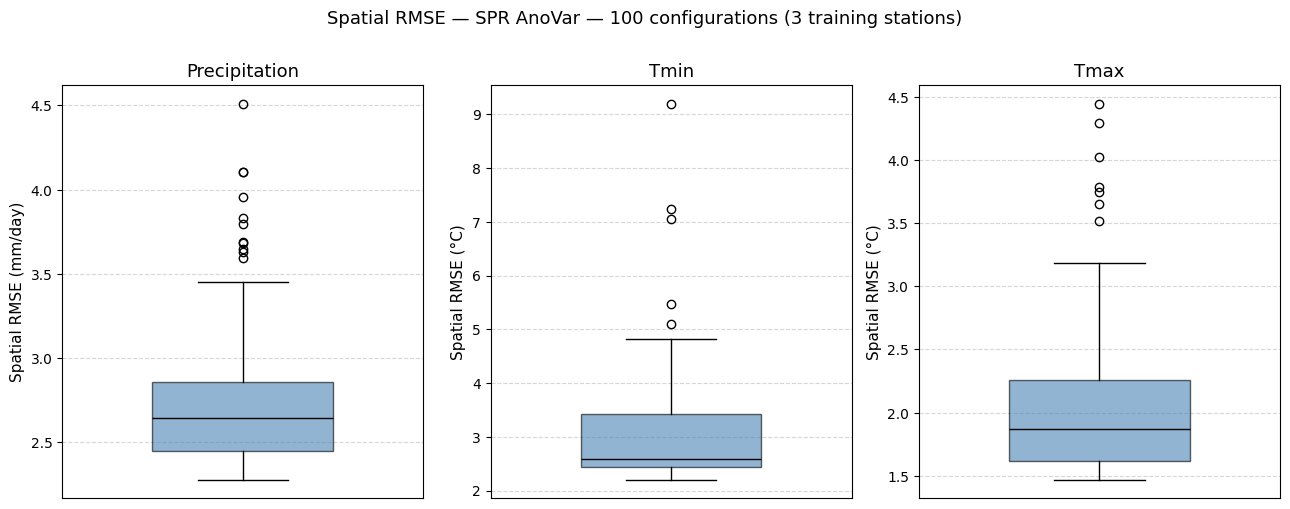

In [12]:
variable_info = [
    (results_pr_ano_var,   "Precipitation", "mm/day"),
    (results_tmin_ano_var, "Tmin",          "°C"),
    (results_tmax_ano_var, "Tmax",          "°C"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=False)
for ax, (df, name, unit) in zip(axes, variable_info):
    ax.boxplot(df['rmse_s'], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='black'))
    ax.set_title(name, fontsize=13)
    ax.set_ylabel(f"Spatial RMSE ({unit})", fontsize=11)
    ax.set_xticks([])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Spatial RMSE — SPR AnoVar — 100 configurations (3 training stations)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

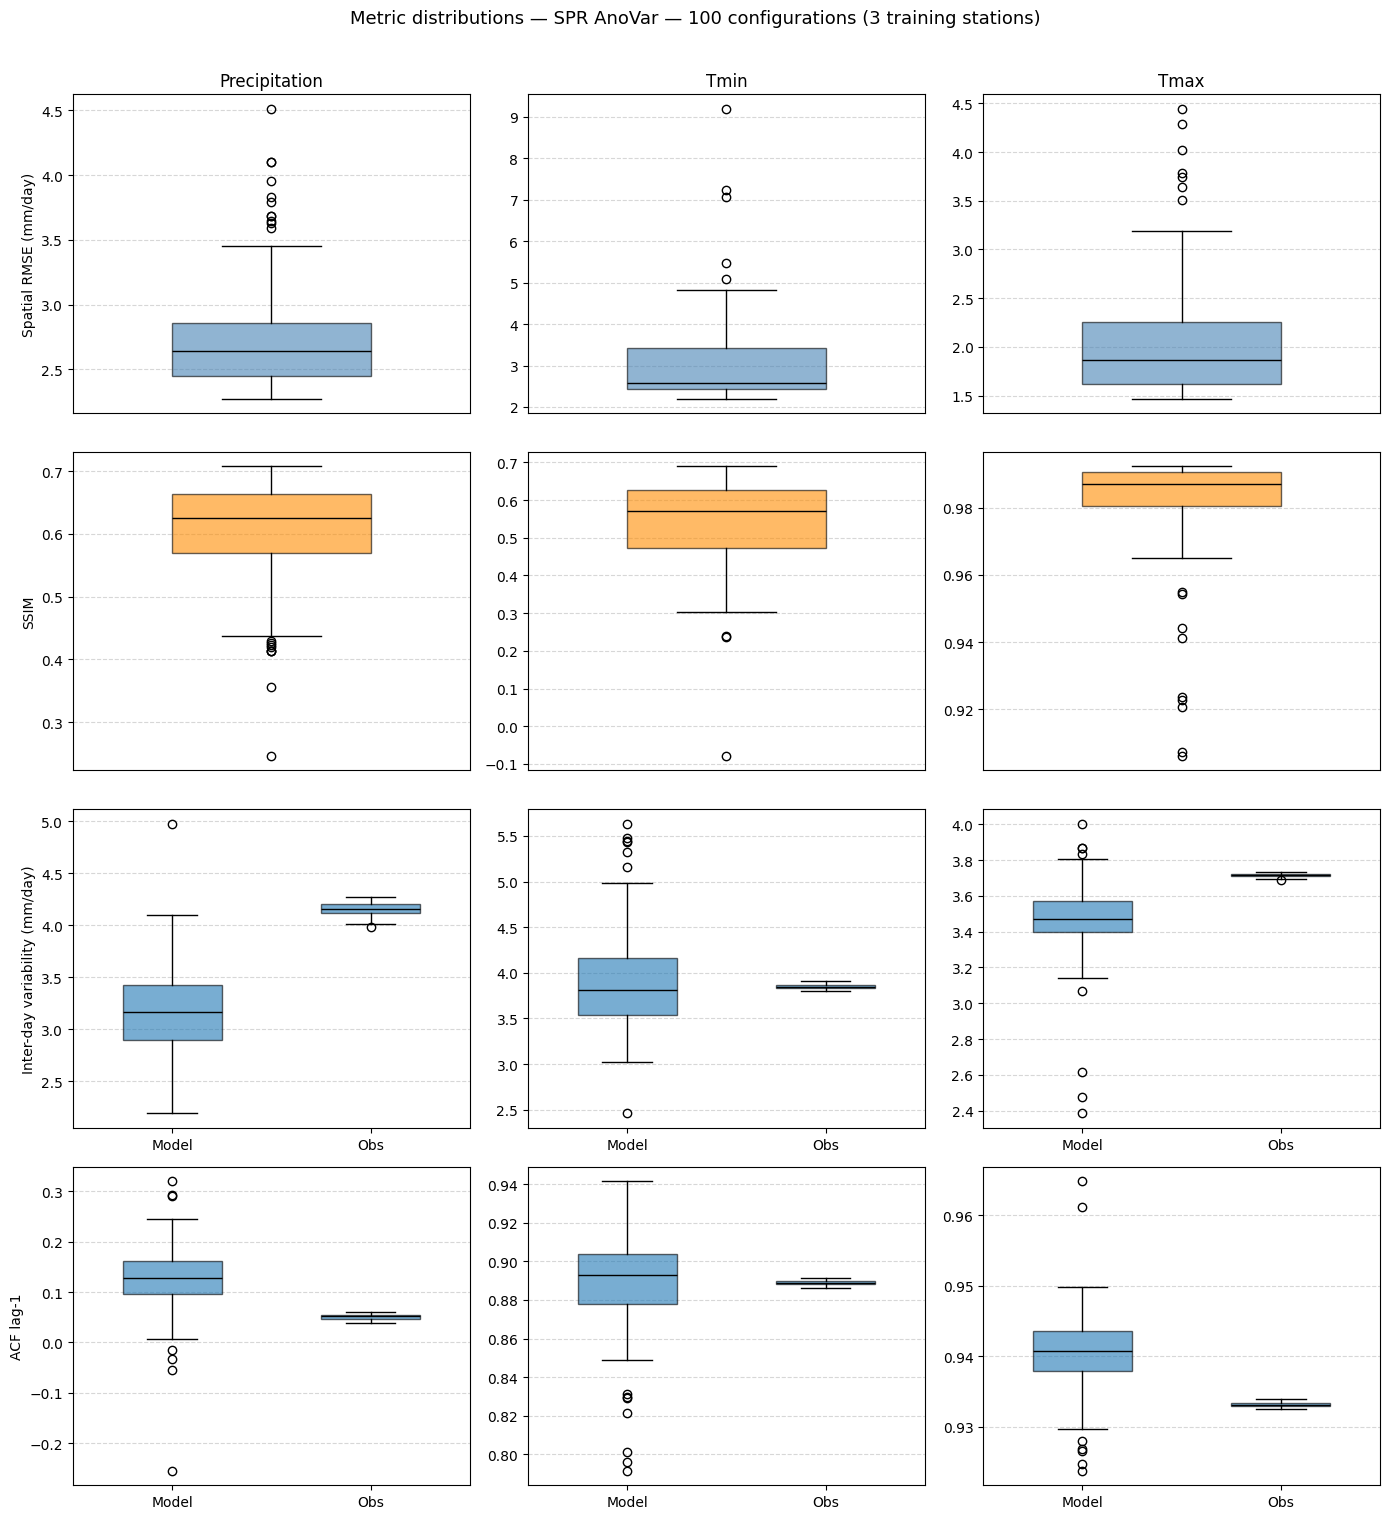

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(14, 15))

for col, (df, name, unit) in enumerate(variable_info):

    # Row 0: Spatial RMSE
    ax = axes[0, col]
    ax.boxplot(df['rmse_s'], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='black'))
    ax.set_title(name, fontsize=12)
    if col == 0:
        ax.set_ylabel(f"Spatial RMSE ({unit})", fontsize=10)
    ax.set_xticks([])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Row 1: SSIM
    ax = axes[1, col]
    ax.boxplot(df['ssim'], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='darkorange', alpha=0.6),
               medianprops=dict(color='black'))
    if col == 0:
        ax.set_ylabel("SSIM", fontsize=10)
    ax.set_xticks([])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Row 2: Inter-day variability (model vs obs)
    ax = axes[2, col]
    ax.boxplot(
        [df['interday_mod'], df['interday_obs']],
        labels=['Model', 'Obs'],
        widths=0.5, patch_artist=True,
        boxprops=dict(alpha=0.6),
        medianprops=dict(color='black')
    )
    if col == 0:
        ax.set_ylabel(f"Inter-day variability ({unit})", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Row 3: ACF lag-1 (model vs obs)
    ax = axes[3, col]
    ax.boxplot(
        [df['acf_lag1_mod'], df['acf_lag1_obs']],
        labels=['Model', 'Obs'],
        widths=0.5, patch_artist=True,
        boxprops=dict(alpha=0.6),
        medianprops=dict(color='black')
    )
    if col == 0:
        ax.set_ylabel("ACF lag-1", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Metric distributions \u2014 SPR AnoVar \u2014 100 configurations (3 training stations)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
